In [12]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [13]:
# 1. Load Dataset

df = pd.read_csv("insurance.csv")
print("First 5 rows:\n", df.head())
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:\n", df.describe())

First 5 rows:
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Summary Statistics:
                age          bmi     chi

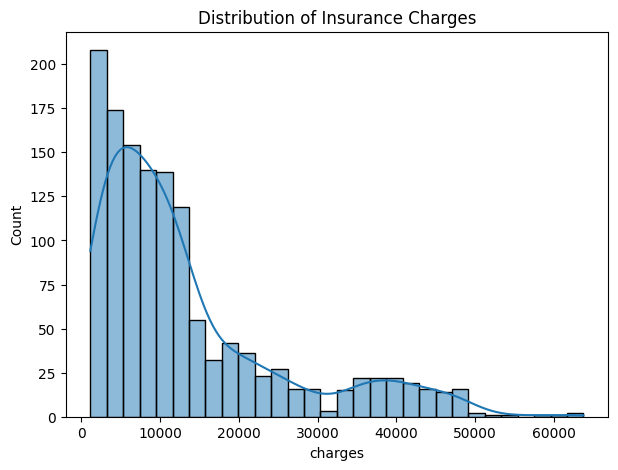

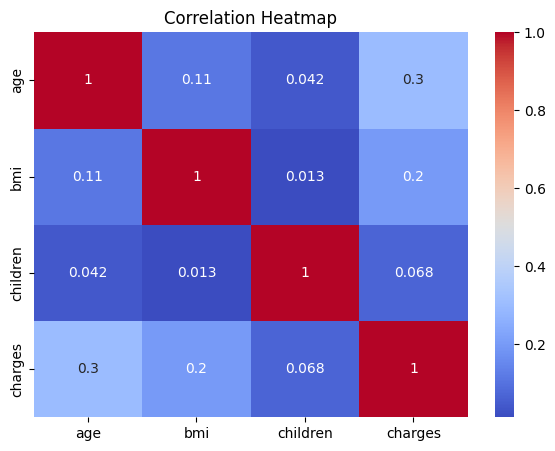

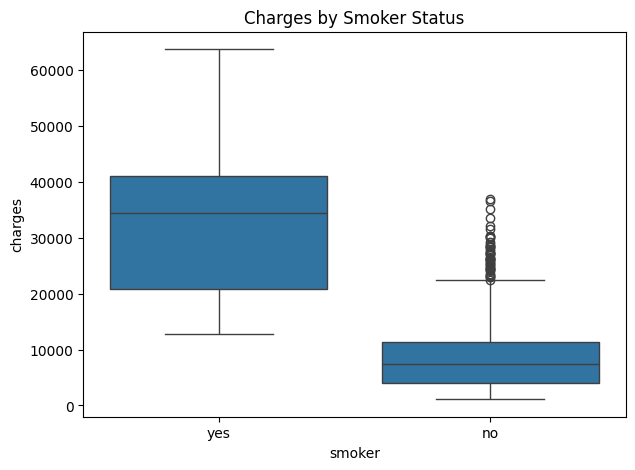

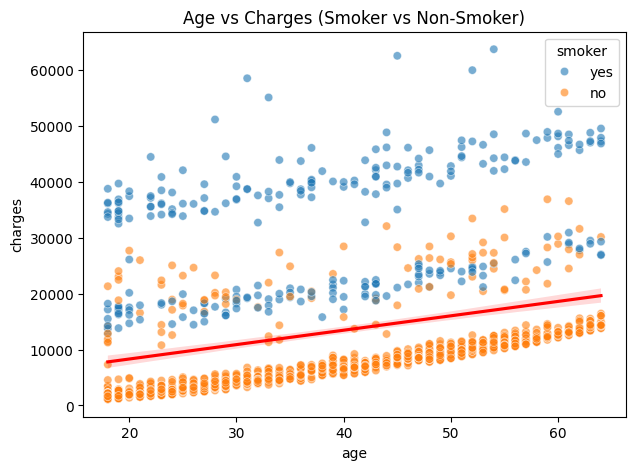

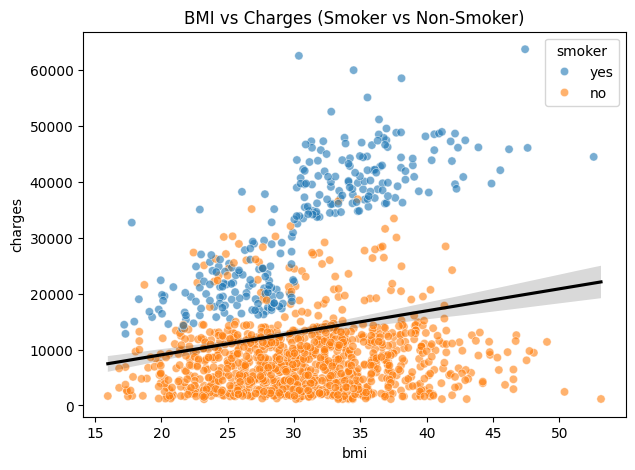

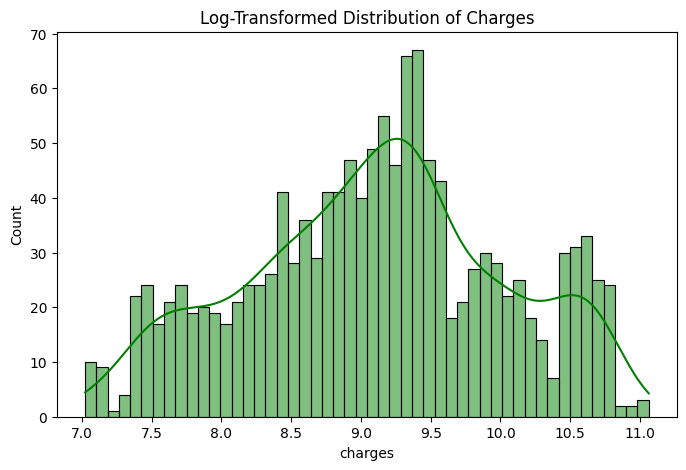

In [31]:
# 2. Exploratory Data Analysis

# Distribution of target
plt.figure(figsize=(7, 5))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Boxplot for Smoker vs Charges
plt.figure(figsize=(7,5))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Charges by Smoker Status")
plt.show()

# Scatter plot with Regression line for Age vs Charges (since heatmap failed to give out any significant insights)
plt.figure(figsize=(7,5))
sns.scatterplot(x="age", y="charges", hue="smoker", data=df, alpha=0.6)
sns.regplot(x="age", y="charges", data=df, scatter=False, color="red")
plt.title("Age vs Charges (Smoker vs Non-Smoker)")
plt.show()

# Scatter plot with trendline for BMI vs Charges
plt.figure(figsize=(7,5))
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df, alpha=0.6)
sns.regplot(x="bmi", y="charges", data=df, scatter=False, color="black")
plt.title("BMI vs Charges (Smoker vs Non-Smoker)")
plt.show()

# Distribution of charges after log transformation
plt.figure(figsize=(8,5))
sns.histplot(np.log(df["charges"] + 1e-8), bins=50, kde=True, color="green")
plt.title("Log-Transformed Distribution of Charges")
plt.show()

In [21]:
# 3. Data Pre-processing

# Convert categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Ensure everything is numeric (important for statsmodels)
df_encoded = df_encoded.astype(float)

print("\nEncoded Columns:\n", df_encoded.columns)

# Features and Target
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Encoded Columns:
 Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


In [22]:
# 4. Model Training (OLS Regression)

# Using statsmodels for OLS summary
X_train_sm = sm.add_constant(X_train)  # Add intercept
ols_model = sm.OLS(y_train, X_train_sm).fit()
print("\nOLS Model Summary:\n", ols_model.summary())


OLS Model Summary:
                             OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     380.9
Date:                Thu, 04 Sep 2025   Prob (F-statistic):          1.32e-305
Time:                        11:09:50   Log-Likelihood:                -10845.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1061   BIC:                         2.175e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1


Evaluation Metrics:
R² Score: 0.7835929767120724
MAE: 4181.19447375365
MSE: 33596915.85136145
RMSE: 5796.284659276273


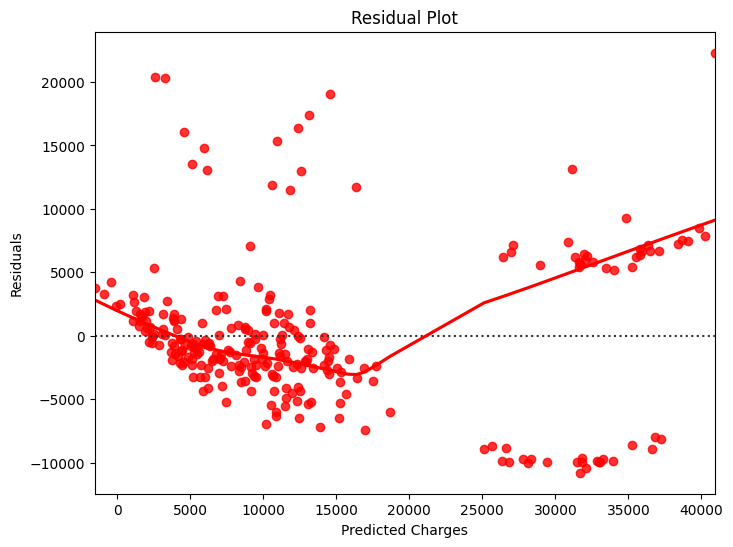

In [23]:
# 5. Model Evaluation
# ------------------------------
y_pred = lr.predict(X_test)

print("\nEvaluation Metrics:")
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Residual Plot
plt.figure(figsize=(8, 6))
sns.residplot(x=y_pred, y=y_test - y_pred, lowess=True, color="red")
plt.title("Residual Plot")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.show()

In [24]:
# 6. Model Tuning
# ------------------------------
# Adding interaction term (BMI * Smoker)
df_encoded["bmi_smoker"] = df_encoded["bmi"] * df_encoded["smoker_yes"]

X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_tuned = LinearRegression()
lr_tuned.fit(X_train, y_train)
y_pred_tuned = lr_tuned.predict(X_test)

print("\nAfter Adding Interaction Term (BMI * Smoker):")
print("R² Score:", r2_score(y_test, y_pred_tuned))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))


After Adding Interaction Term (BMI * Smoker):
R² Score: 0.8652503208873078
RMSE: 4573.807686290384
